In [1]:
import numpy as np
from numpy import linalg as LA
from matplotlib import pyplot as plt

In [2]:
GRAVITY = 9.80665

In [3]:
# https://ja.aliexpress.com/item/1005003954474597.html?gatewayAdapt=glo2jpn
throttle = np.array([0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0])
torque = np.array([0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.13, 0.14, 0.15, 0.17, 0.18, 0.19])
thrust = np.array([214.74, 262.99, 318.19, 395.34, 470.2, 563.18, 652.18, 742.76, 831.48, 933.89, 1026.93, 1120.55, 1214.82, 1298.91, 1367.04]) * GRAVITY * 1e-3
voltage = np.array([16.1, 16.1, 16.1, 16.09, 16.08, 16.07, 16.06, 16.05, 16.03, 16.02, 15.99, 15.98, 15.96, 15.94, 15.92])
rpm = np.array([4269., 4745., 5203., 5740., 6252., 6804., 7339., 7801., 8282., 8719., 9137., 9574., 10068., 10447., 10703.])


Motor Constant: 1.0792178536767292e-05


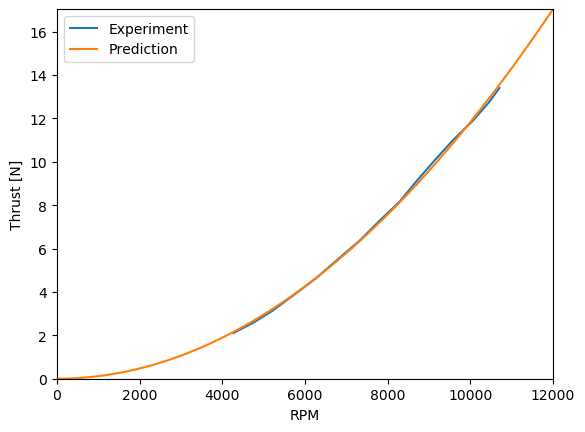

In [4]:
omega = rpm * np.pi / 30
omega2 = omega**2
motor_const = (thrust.T @ omega2) / (omega2.T @ omega2)
print(f'Motor Constant: {motor_const}')

rpm_pred = np.linspace(0., 12000., 1000)
omega_pred = rpm_pred * np.pi / 30
thrust_pred = motor_const * omega_pred**2
plt.plot(rpm, thrust, label="Experiment")
plt.plot(rpm_pred, motor_const * omega_pred**2, label="Prediction")
plt.xlabel("RPM")
plt.ylabel("Thrust [N]")
plt.xlim(0, rpm_pred.max())
plt.ylim(0, thrust_pred.max())
plt.legend()
plt.show()

Moment Constant: 0.01409853018537201


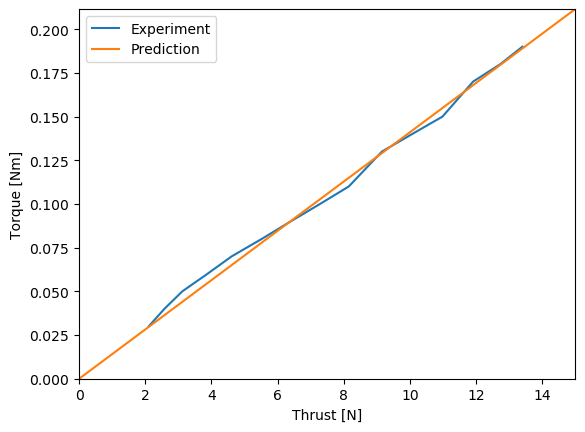

In [5]:
moment_constant = (torque.T @ thrust) / (thrust.T @ thrust)
print(f'Moment Constant: {moment_constant}')

thrust_pred = np.linspace(0., 15., 1000)
torque_pred = moment_constant * thrust_pred
plt.plot(thrust, torque, label="Experiment")
plt.plot(thrust_pred, moment_constant * thrust_pred, label="Prediction")
plt.xlabel("Thrust [N]")
plt.ylabel("Torque [Nm]")
plt.xlim(0, thrust_pred.max())
plt.ylim(0, torque_pred.max())
plt.legend()
plt.show()

Coefficients: (0.0009834662554429252, 4.544169227624464e-08)


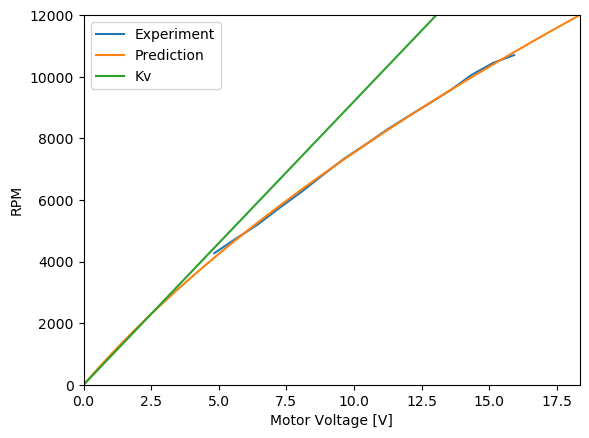

In [6]:
motor_voltage = throttle * voltage
kv = 920

X = np.c_[rpm, rpm**2]
a, b = LA.lstsq(X, motor_voltage, rcond=None)[0]
print(f'Coefficients: {a, b}')

motor_voltage_pred = a * rpm_pred + b * rpm_pred**2
plt.plot(motor_voltage, rpm, label="Experiment")
plt.plot(motor_voltage_pred, rpm_pred, label="Prediction")
plt.plot(motor_voltage_pred, motor_voltage_pred * kv, label="Kv")
plt.xlabel("Motor Voltage [V]")
plt.ylabel("RPM")
plt.xlim(0, motor_voltage_pred.max())
plt.ylim(0, rpm_pred.max())
plt.legend()
plt.show()
